In [78]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Question 1

In [79]:
df = pd.read_csv('train.csv')
df.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [80]:
train, test = train_test_split(df, test_size=0.1, stratify=df['target'], random_state=0)
print("Train size:", len(train), "Test size:", len(test))

Train size: 6851 Test size: 762


In [81]:
df.describe()

,id,target
count,7613.000000,7613.00000
mean,5441.934848,0.42966
std,3137.116090,0.49506
min,1.000000,0.00000
25%,2734.000000,0.00000
50%,5408.000000,0.00000
75%,8146.000000,1.00000
max,10873.000000,1.00000


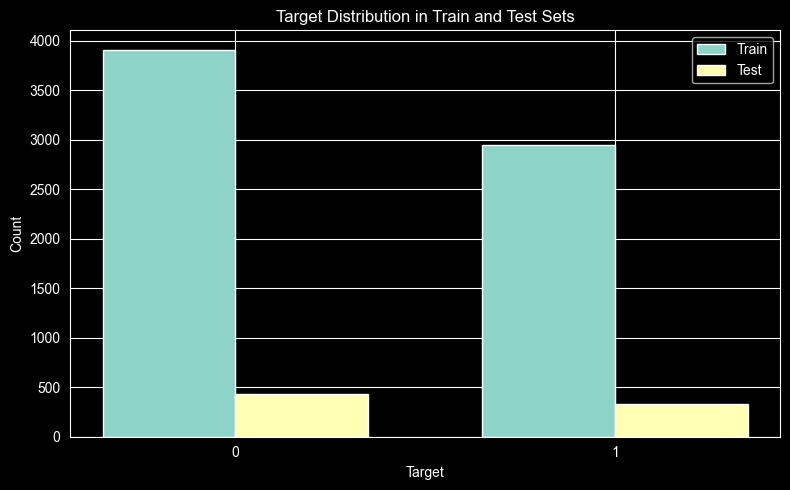

Train - Target 0: 3907 Target 1: 2944
Test - Target 0: 435 Target 1: 327
Train ratio (1/total): 0.429718289300832
Test ratio (1/total): 0.42913385826771655


In [82]:
train_counts = train['target'].value_counts().sort_index()
test_counts = test['target'].value_counts().sort_index()

x = np.arange(len(train_counts))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width / 2, train_counts.values, width, label='Train')
ax.bar(x + width / 2, test_counts.values, width, label='Test')

ax.set_xlabel('Target')
ax.set_ylabel('Count')
ax.set_title('Target Distribution in Train and Test Sets')
ax.set_xticks(x)
ax.set_xticklabels(train_counts.index)
ax.legend()
plt.tight_layout()
plt.show()

print("Train - Target 0:", train_counts[0], "Target 1:", train_counts[1])
print("Test - Target 0:", test_counts[0], "Target 1:", test_counts[1])
print("Train ratio (1/total):", train_counts[1] / (train_counts[0] + train_counts[1]))
print("Test ratio (1/total):", test_counts[1] / (test_counts[0] + test_counts[1]))

The dataset is imbalanced. Target 1 represents ~43% of the data, while target 0 represents ~57%.

# Question 2

In [83]:
train.drop(columns=['id', 'location'],inplace=True)

In [84]:
train.columns

Index(['keyword', 'text', 'target'], dtype='object')

In [85]:
test.drop(columns=['id', 'location'],inplace=True)

In [86]:
test.columns

Index(['keyword', 'text', 'target'], dtype='object')

In [87]:
train.isna().sum()

keyword    54
text        0
target      0
dtype: int64

In [88]:
train['keyword']=train['keyword'].fillna('null')
test['keyword']=test['keyword'].fillna('null')

In [89]:
train.isna().sum()

keyword    0
text       0
target     0
dtype: int64

In [90]:
train['inputs'] = train['keyword'] + ' ' + train['text']
test['inputs'] = test['keyword'] + ' ' + test['text']

# Question 3